In [10]:
import os
import shutil
import zipfile
import numpy as np

# =========================
# Assignment 2
# Faster revised main code (no plot block)
# - Radius read from blade file
# - Full generator torque law in all regions
# - Above-rated validation based on P_mech
# - Pitch actuator rate limit included
# - Øye dynamic inflow kept for above-rated and turbulent cases
# - Below-rated kept quasi-steady for speed
# - omega_ref_factor fixed by default in main()
# - Optional omega_ref screening kept as a separate helper
# =========================

# -------- Files --------
DATA_DIR = "."
BLADE_FILE = os.path.join(DATA_DIR, "bladedat.txt")

AIRFOIL_FILES = {
    100.0: os.path.join(DATA_DIR, "cylinder_ds.txt"),
    24.1: os.path.join(DATA_DIR, "FFA-W3-241_ds.txt"),
    30.1: os.path.join(DATA_DIR, "FFA-W3-301_ds.txt"),
    36.0: os.path.join(DATA_DIR, "FFA-W3-360_ds.txt"),
    48.0: os.path.join(DATA_DIR, "FFA-W3-480_ds.txt"),
    60.0: os.path.join(DATA_DIR, "FFA-W3-600_ds.txt"),
}

# -------- Turbine constants --------
B = 3
rho = 1.225
ROTOR_R = None  # set in main()

# -------- Assignment 2 constants --------
P_RATED = 10.64e6
I_DRIVETRAIN = 1.6e8

KP = 1.5
KI = 0.64
KK_DEG = 14.0

THETA_MIN_DEG = 0.0
THETA_MAX_DEG = 90.0
PITCH_RATE_MAX_DEG_S = 8.0

# -------- Numerical settings --------
dt = 0.15
Nsec = 40

F_RELAX = 0.35
TOL_RES = 1e-4
ITMAX = 80

WARM_START = True

# -------- Dynamic inflow usage --------
USE_DYNAMIC_INFLOW_BELOW = False   # faster for steady below-rated verification
USE_DYNAMIC_INFLOW_ABOVE = True
USE_DYNAMIC_INFLOW_TURB = True

# -------- Øye model constants --------
OYE_K = 0.6
OYE_DENOM_MIN = 0.05

# -------- Prior results / assumptions from Assignment 1 --------
CP_MAX = 0.48
LAMBDA_OPT = 7.8
THETA_P_OPT_DEG = 0.0

# -------- Default omega_ref choice --------
DEFAULT_OMEGA_REF_FACTOR = 1.02

# -------- Optional screening candidates --------
OMEGA_REF_CANDIDATES = [1.00, 1.01, 1.02, 1.03, 1.04]
OMEGA_REF_TUNE_WIND = 15.0
OMEGA_REF_TUNE_TEND = 120.0

# -------- Default wind sweeps --------
DEFAULT_V0_BELOW = np.arange(4.0, 12.0, 1.0)
DEFAULT_V0_ABOVE = np.array([12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 20.0, 23.0])

# -------- Turbulence inputs --------
H_HUB = 119.0
TURB_ZIP_FILE = os.path.join(DATA_DIR, "Turbulence_generator.zip")
TURB_EXTRACT_DIR = os.path.join(DATA_DIR, "Turbulence_generator")
TURB_INP_FILE = os.path.join(TURB_EXTRACT_DIR, "inputEx3.inp")
TURB_U_FILE = os.path.join(DATA_DIR, "sim1.bin")


def rotor_radius():
    if ROTOR_R is None:
        raise RuntimeError("ROTOR_R has not been initialised yet. Call main() first.")
    return ROTOR_R


def rotor_area(R=None):
    Ruse = rotor_radius() if R is None else float(R)
    return np.pi * Ruse ** 2


# =========================
# 1) Read blade geometry + build sections
# =========================
def read_bladedat(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing blade file: {path}")

    data = np.loadtxt(path)
    if data.ndim != 2 or data.shape[1] < 4:
        raise ValueError("bladedat.txt must have >= 4 columns")

    r = data[:, 0]
    tc = data[:, 3]
    beta_deg = data[:, 1]
    c = data[:, 2]

    if np.nanmax(tc) <= 1.5:
        tc = tc * 100.0

    idx = np.argsort(r)
    return r[idx], c[idx], beta_deg[idx], tc[idx]


def build_sections(r_tab, c_tab, beta_deg_tab, tc_tab, nsec):
    r0 = float(np.min(r_tab))
    Rtip = float(np.max(r_tab))
    r_sec = np.linspace(r0, 0.98 * Rtip, nsec)

    c_sec = np.interp(r_sec, r_tab, c_tab)
    beta_deg_sec = np.interp(r_sec, r_tab, beta_deg_tab)
    tc_sec = np.interp(r_sec, r_tab, tc_tab)

    return Rtip, r_sec, c_sec, beta_deg_sec, tc_sec


# =========================
# 2) Read polars + interpolation with extrapolation
# =========================
def read_polar_file(path):
    tbl = np.loadtxt(path, ndmin=2)
    if tbl.shape[1] < 3:
        raise ValueError(f"{path} must have >= 3 columns: alpha, Cl, Cd")

    alpha = tbl[:, 0]
    cl = tbl[:, 1]
    cd = tbl[:, 2]

    order = np.argsort(alpha)
    return alpha[order], cl[order], cd[order]


def load_airfoils(files_dict):
    items = sorted(files_dict.items(), key=lambda kv: kv[0])
    thick = np.array([tc for tc, _ in items], dtype=float)

    aoa_cols, cl_cols, cd_cols = [], [], []
    for _, fname in items:
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing airfoil file: {fname}")

        a, cl, cd = read_polar_file(fname)
        aoa_cols.append(a)
        cl_cols.append(cl)
        cd_cols.append(cd)

    return thick, aoa_cols, cl_cols, cd_cols


THICK, AOA_COLS, CL_COLS, CD_COLS = load_airfoils(AIRFOIL_FILES)


def interp_extrap(x, xp, yp):
    x = float(x)
    xp = np.asarray(xp, dtype=float)
    yp = np.asarray(yp, dtype=float)

    if x <= xp[0]:
        x0, x1 = xp[0], xp[1]
        y0, y1 = yp[0], yp[1]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    if x >= xp[-1]:
        x0, x1 = xp[-2], xp[-1]
        y0, y1 = yp[-2], yp[-1]
        return y1 + (y1 - y0) * (x - x1) / (x1 - x0)

    return float(np.interp(x, xp, yp))


def cl_cd_double_interp(alpha_deg, tc_percent):
    tc = float(np.clip(tc_percent, THICK.min(), THICK.max()))
    cl_thk = np.empty(len(THICK))
    cd_thk = np.empty(len(THICK))

    for k in range(len(THICK)):
        cl_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CL_COLS[k])
        cd_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CD_COLS[k])

    cl = float(np.interp(tc, THICK, cl_thk))
    cd = float(np.interp(tc, THICK, cd_thk))
    return cl, cd


# =========================
# 3) Prandtl tip loss
# =========================
def prandtl_tip_loss(B, r, R, phi):
    sphi = abs(np.sin(phi))
    sphi = max(sphi, 1e-12)

    ftip = (B * (R - r)) / (2.0 * r * sphi)
    ftip = max(0.0, ftip)

    F = (2.0 / np.pi) * np.arccos(np.exp(-ftip))
    return float(np.clip(F, 1e-6, 1.0))


# =========================
# 4) Quasi-steady solve a/ap
# =========================
def solve_a_ap_qs(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a_init, ap_init):
    R = rotor_radius()

    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    a = a_init
    ap = ap_init

    a_new = 0.10 if a_init == 0.0 else a_init
    ap_new = 0.00 if ap_init == 0.0 else ap_init

    it = 0
    while True:
        it += 1
        a, ap = a_new, ap_new

        denom = (1.0 + ap) * Omega * r + 1e-12
        phi = np.arctan(((1.0 - a) * V0) / denom)
        alpha_deg = np.rad2deg(phi - (twist + theta_p))

        Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

        Cn = Cl * np.cos(phi) + Cd * np.sin(phi)
        Ct = Cl * np.sin(phi) - Cd * np.cos(phi)

        sigma = (B * chord) / (2.0 * np.pi * r + 1e-12)
        F = prandtl_tip_loss(B, r, R, phi)

        sphi = np.sin(phi)
        cphi = np.cos(phi)

        a_fix = (sigma * Cn * (1.0 - a)) / (4.0 * F * (sphi ** 2) + 1e-12)
        ap_fix = (sigma * Ct * (1.0 + ap)) / (4.0 * F * sphi * cphi + 1e-12)

        if a > 0.33:
            dCT = ((1.0 - a) ** 2 * Cn * sigma) / (sphi ** 2 + 1e-12)
            a_fix = dCT / (4.0 * F * (1.0 - 0.25 * (5.0 - 3.0 * a) * a) + 1e-12)

        a_new = a + F_RELAX * (a_fix - a)
        ap_new = ap + F_RELAX * (ap_fix - ap)

        if max(abs(a_fix - a), abs(ap_fix - ap)) < TOL_RES or it >= ITMAX:
            return a_new, ap_new


# =========================
# 5) Loads from a/ap
# =========================
def loads_from_a_ap(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a, ap):
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    denom = (1.0 + ap) * Omega * r + 1e-12
    phi = np.arctan(((1.0 - a) * V0) / denom)
    alpha_deg = np.rad2deg(phi - (twist + theta_p))

    Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

    Vrel = np.sqrt(((1.0 - a) * V0) ** 2 + ((1.0 + ap) * Omega * r) ** 2)
    L = 0.5 * rho * Vrel ** 2 * chord * Cl
    D = 0.5 * rho * Vrel ** 2 * chord * Cd

    fT = L * np.sin(phi) - D * np.cos(phi)
    fN = L * np.cos(phi) + D * np.sin(phi)
    return fN, fT


# =========================
# 6) Øye dynamic inflow helpers
# =========================
def oye_time_constants(V0, a, r):
    R = rotor_radius()
    V0 = max(float(V0), 0.1)
    a = float(np.clip(a, 0.0, 0.95))
    denom = max(1.0 - 1.3 * a, OYE_DENOM_MIN)

    tau1 = (1.1 / denom) * (R / V0)
    tau2 = (0.39 - 0.26 * (r / R) ** 2) * tau1
    return float(tau1), float(max(tau2, 1e-6))


def init_dynamic_inflow_states(a_state, Vz_local):
    Wz_state = -np.asarray(a_state, dtype=float) * np.asarray(Vz_local, dtype=float)
    Wint_state = Wz_state.copy()
    Wqs_prev = Wz_state.copy()
    return Wz_state, Wint_state, Wqs_prev


def update_dynamic_inflow(a_qs, a_actual, V0, r, dt_local, Wz_state, Wint_state, Wqs_prev, use_dynamic_inflow):
    if not use_dynamic_inflow:
        Wz_new = -a_qs * V0
        return float(np.clip(a_qs, 0.0, 0.95)), Wz_new, Wz_new, Wz_new

    Wqs = -a_qs * V0
    tau1, tau2 = oye_time_constants(V0, a_actual, r)

    fac1 = dt_local / tau1
    fac2 = dt_local / tau2

    Wint_new = Wint_state + fac1 * (Wqs - Wint_state) + OYE_K * (Wqs - Wqs_prev)
    Wz_new = Wz_state + fac2 * (Wint_new - Wz_state)
    a_new = np.clip(-Wz_new / max(V0, 0.1), 0.0, 0.95)

    return float(a_new), float(Wz_new), float(Wint_new), float(Wqs)


# =========================
# 7) Warm start
# =========================
def warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg, Omega):
    for j in range(len(r_sec)):
        a_state[j], ap_state[j] = solve_a_ap_qs(
            Vz_local[j],
            Omega,
            r_sec[j],
            c_sec[j],
            beta_deg_sec[j],
            pitch_deg,
            tc_sec[j],
            a_state[j],
            ap_state[j],
        )
    return init_dynamic_inflow_states(a_state, Vz_local)


# =========================
# 8) Steady rotor performance helper
# =========================
def rotor_performance_steady(V0, Omega, pitch_deg, r_sec, c_sec, beta_deg_sec, tc_sec):
    A = rotor_area()

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))

    fN = np.zeros(len(r_sec))
    fT = np.zeros(len(r_sec))

    for j in range(len(r_sec)):
        a_state[j], ap_state[j] = solve_a_ap_qs(
            V0, Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j], a_state[j], ap_state[j]
        )

        fN[j], fT[j] = loads_from_a_ap(
            V0, Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j], a_state[j], ap_state[j]
        )

    T_blade = np.trapezoid(fN, r_sec)
    Q_blade = np.trapezoid(fT * r_sec, r_sec)
    P_blade = Omega * Q_blade

    T_total = B * T_blade
    Q_total = B * Q_blade
    P_total = B * P_blade

    Cp = P_total / (0.5 * rho * A * V0 ** 3)
    Ct = T_total / (0.5 * rho * A * V0 ** 2)

    return {"T": T_total, "Q": Q_total, "P": P_total, "Cp": Cp, "Ct": Ct}


# =========================
# 9) Rated conditions
# =========================
def determine_rated_conditions(lambda_opt, theta_p_opt_deg, r_sec, c_sec, beta_deg_sec, tc_sec,
                               omega_ref_factor=DEFAULT_OMEGA_REF_FACTOR,
                               v_min=6.0, v_max=20.0, tol=1e-5, max_iter=100):
    R = rotor_radius()

    def rated_power_residual(V):
        Omega = lambda_opt * V / R
        out = rotor_performance_steady(V, Omega, theta_p_opt_deg, r_sec, c_sec, beta_deg_sec, tc_sec)
        return out["P"] - P_RATED

    a = float(v_min)
    b = float(v_max)
    fa = rated_power_residual(a)
    fb = rated_power_residual(b)

    if fa * fb > 0.0:
        raise ValueError("Could not bracket V_rated. Adjust v_min / v_max.")

    for _ in range(max_iter):
        m = 0.5 * (a + b)
        fm = rated_power_residual(m)

        if abs(fm) < tol:
            V_rated = m
            break

        if fa * fm < 0.0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm
    else:
        V_rated = 0.5 * (a + b)

    omega_rated = lambda_opt * V_rated / R
    K = P_RATED / (omega_rated ** 3)
    omega_ref = omega_ref_factor * omega_rated

    return {
        "V_rated": float(V_rated),
        "omega_rated": float(omega_rated),
        "K": float(K),
        "omega_ref": float(omega_ref),
        "omega_ref_factor": float(omega_ref_factor),
    }


def generator_torque(omega, K, omega_rated):
    if omega < omega_rated:
        return K * omega ** 2
    return P_RATED / max(omega, 1e-12)


# =========================
# 10) Controller helpers
# =========================
def clamp(x, xmin, xmax):
    return max(xmin, min(x, xmax))


def gain_reduction(theta_p_deg):
    return 1.0 / (1.0 + theta_p_deg / KK_DEG)


def apply_pitch_rate_limit(pitch_deg, theta_set_deg, dt_local):
    dpitch_max = PITCH_RATE_MAX_DEG_S * dt_local
    dpitch = np.clip(theta_set_deg - pitch_deg, -dpitch_max, dpitch_max)
    return clamp(pitch_deg + dpitch, THETA_MIN_DEG, THETA_MAX_DEG)


def update_collective_pitch_controller(omega, rated, pitch_deg, theta_I_deg, dt_local):
    error = omega - rated["omega_ref"]
    GK = gain_reduction(pitch_deg)

    theta_P_deg = np.rad2deg(KP * error) * GK
    theta_I_trial = theta_I_deg + np.rad2deg(KI * error * dt_local) * GK
    theta_set_trial = theta_P_deg + theta_I_trial

    is_saturating_high = theta_set_trial > THETA_MAX_DEG and error > 0.0
    is_saturating_low = theta_set_trial < THETA_MIN_DEG and error < 0.0

    if not (is_saturating_high or is_saturating_low):
        theta_I_deg = theta_I_trial

    theta_I_deg = clamp(theta_I_deg, THETA_MIN_DEG, THETA_MAX_DEG)
    theta_set_deg = clamp(theta_P_deg + theta_I_deg, THETA_MIN_DEG, THETA_MAX_DEG)
    pitch_deg = apply_pitch_rate_limit(pitch_deg, theta_set_deg, dt_local)

    return pitch_deg, theta_I_deg, error


# =========================
# 11) Below-rated constant-wind case
# =========================
def run_below_rated_case(V0, r_sec, c_sec, beta_deg_sec, tc_sec, rated, T_end=80.0, omega_init=None):
    A = rotor_area()
    R = rotor_radius()

    n_steps = int(np.floor(T_end / dt)) + 1
    pitch_deg = THETA_P_OPT_DEG

    if omega_init is None:
        omega_init = 0.6 * LAMBDA_OPT * V0 / R

    omega = float(max(omega_init, 0.05))

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))
    Vz_local = np.full_like(r_sec, V0, dtype=float)

    t_hist, omega_hist, lambda_hist = [], [], []
    Cp_hist, Pmech_hist, Pel_hist = [], [], []
    T_hist = []

    for k in range(n_steps):
        t = k * dt

        fN = np.zeros_like(r_sec)
        fT = np.zeros_like(r_sec)

        for j in range(len(r_sec)):
            a_state[j], ap_state[j] = solve_a_ap_qs(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j], a_state[j], ap_state[j]
            )

            fN[j], fT[j] = loads_from_a_ap(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j], a_state[j], ap_state[j]
            )

        T_blade = np.trapezoid(fN, r_sec)
        Q_blade = np.trapezoid(fT * r_sec, r_sec)

        T_total = B * T_blade
        Q_aero = B * Q_blade
        P_mech = omega * Q_aero

        M_gen = generator_torque(omega, rated["K"], rated["omega_rated"])
        P_el = M_gen * omega

        omega = omega + dt * (Q_aero - M_gen) / I_DRIVETRAIN
        omega = max(omega, 0.05)

        lambda_now = omega * R / V0
        Cp_now = P_mech / (0.5 * rho * A * V0 ** 3)

        t_hist.append(t)
        omega_hist.append(omega)
        lambda_hist.append(lambda_now)
        Cp_hist.append(Cp_now)
        Pmech_hist.append(P_mech)
        Pel_hist.append(P_el)
        T_hist.append(T_total)

    t_hist = np.asarray(t_hist, dtype=float)
    omega_hist = np.asarray(omega_hist, dtype=float)
    lambda_hist = np.asarray(lambda_hist, dtype=float)
    Cp_hist = np.asarray(Cp_hist, dtype=float)
    Pmech_hist = np.asarray(Pmech_hist, dtype=float)
    Pel_hist = np.asarray(Pel_hist, dtype=float)
    T_hist = np.asarray(T_hist, dtype=float)

    n_tail = max(10, int(0.2 * len(t_hist)))

    return {
        "V0": float(V0),
        "t": t_hist,
        "omega": omega_hist,
        "lambda": lambda_hist,
        "Cp": Cp_hist,
        "P_mech": Pmech_hist,
        "P_el": Pel_hist,
        "T_total": T_hist,
        "pitch_deg": pitch_deg,
        "omega_final": float(np.mean(omega_hist[-n_tail:])),
        "lambda_final": float(np.mean(lambda_hist[-n_tail:])),
        "Cp_final": float(np.mean(Cp_hist[-n_tail:])),
        "P_mech_final": float(np.mean(Pmech_hist[-n_tail:])),
        "P_el_final": float(np.mean(Pel_hist[-n_tail:])),
        "T_final": float(np.mean(T_hist[-n_tail:])),
    }


def run_below_rated_sweep(r_sec, c_sec, beta_deg_sec, tc_sec, rated, V0_list=None, T_end=80.0):
    if V0_list is None:
        V0_list = DEFAULT_V0_BELOW
    return [
        run_below_rated_case(V0, r_sec, c_sec, beta_deg_sec, tc_sec, rated, T_end=T_end)
        for V0 in np.asarray(V0_list, dtype=float)
    ]


def print_below_rated_summary(results):
    print("\nBelow-rated steady results:")
    print(
        f"{'V0 [m/s]':>9} {'omega_f [rad/s]':>16} {'lambda_f':>12} "
        f"{'Cp_f':>12} {'d_lambda':>12} {'d_Cp':>12} {'P_mech [MW]':>14}"
    )

    for case in results:
        d_lambda = case["lambda_final"] - LAMBDA_OPT
        d_cp = case["Cp_final"] - CP_MAX
        print(
            f"{case['V0']:9.3f} {case['omega_final']:16.6f} {case['lambda_final']:12.6f} "
            f"{case['Cp_final']:12.6f} {d_lambda:12.6f} {d_cp:12.6f} {case['P_mech_final']/1e6:14.6f}"
        )


# =========================
# 12) Above-rated constant-wind case
# =========================
def run_above_rated_case(V0, r_sec, c_sec, beta_deg_sec, tc_sec, rated,
                         T_end=80.0, omega_init=None, pitch_init_deg=0.0):
    R = rotor_radius()
    n_steps = int(np.floor(T_end / dt)) + 1

    if omega_init is None:
        omega_init = rated["omega_rated"]

    omega = float(max(omega_init, 0.05))
    pitch_deg = float(clamp(pitch_init_deg, THETA_MIN_DEG, THETA_MAX_DEG))
    theta_I_deg = float(clamp(pitch_deg, THETA_MIN_DEG, THETA_MAX_DEG))

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))
    Vz_local = np.full_like(r_sec, V0, dtype=float)

    if WARM_START:
        Wz_state, Wint_state, Wqs_prev = warm_start_induction(
            a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg, omega
        )
    else:
        Wz_state, Wint_state, Wqs_prev = init_dynamic_inflow_states(a_state, Vz_local)

    t_hist, omega_hist, pitch_hist = [], [], []
    lambda_hist, Pmech_hist, Pel_hist = [], [], []
    T_hist, err_hist = [], []

    for k in range(n_steps):
        t = k * dt

        fN = np.zeros_like(r_sec)
        fT = np.zeros_like(r_sec)

        for j in range(len(r_sec)):
            a_qs, ap_qs = solve_a_ap_qs(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j], a_state[j], ap_state[j]
            )
            a_state[j], Wz_state[j], Wint_state[j], Wqs_prev[j] = update_dynamic_inflow(
                a_qs, a_state[j], Vz_local[j], r_sec[j], dt,
                Wz_state[j], Wint_state[j], Wqs_prev[j], USE_DYNAMIC_INFLOW_ABOVE
            )
            ap_state[j] = ap_qs

            fN[j], fT[j] = loads_from_a_ap(
                Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j], a_state[j], ap_state[j]
            )

        T_blade = np.trapezoid(fN, r_sec)
        Q_blade = np.trapezoid(fT * r_sec, r_sec)

        T_total = B * T_blade
        Q_aero = B * Q_blade
        P_mech = omega * Q_aero

        M_gen = generator_torque(omega, rated["K"], rated["omega_rated"])
        P_el = M_gen * omega

        pitch_deg, theta_I_deg, error = update_collective_pitch_controller(
            omega, rated, pitch_deg, theta_I_deg, dt
        )

        omega = omega + dt * (Q_aero - M_gen) / I_DRIVETRAIN
        omega = max(omega, 0.05)

        lambda_now = omega * R / V0

        t_hist.append(t)
        omega_hist.append(omega)
        pitch_hist.append(pitch_deg)
        lambda_hist.append(lambda_now)
        Pmech_hist.append(P_mech)
        Pel_hist.append(P_el)
        T_hist.append(T_total)
        err_hist.append(error)

    t_hist = np.asarray(t_hist, dtype=float)
    omega_hist = np.asarray(omega_hist, dtype=float)
    pitch_hist = np.asarray(pitch_hist, dtype=float)
    lambda_hist = np.asarray(lambda_hist, dtype=float)
    Pmech_hist = np.asarray(Pmech_hist, dtype=float)
    Pel_hist = np.asarray(Pel_hist, dtype=float)
    T_hist = np.asarray(T_hist, dtype=float)
    err_hist = np.asarray(err_hist, dtype=float)

    n_tail = max(10, int(0.2 * len(t_hist)))
    sat_frac = float(np.mean((pitch_hist <= THETA_MIN_DEG + 1e-9) | (pitch_hist >= THETA_MAX_DEG - 1e-9)))

    return {
        "V0": float(V0),
        "t": t_hist,
        "omega": omega_hist,
        "pitch_deg": pitch_hist,
        "lambda": lambda_hist,
        "P_mech": Pmech_hist,
        "P_el": Pel_hist,
        "T_total": T_hist,
        "omega_error": err_hist,
        "omega_final": float(np.mean(omega_hist[-n_tail:])),
        "pitch_final_deg": float(np.mean(pitch_hist[-n_tail:])),
        "lambda_final": float(np.mean(lambda_hist[-n_tail:])),
        "P_mech_final": float(np.mean(Pmech_hist[-n_tail:])),
        "P_el_final": float(np.mean(Pel_hist[-n_tail:])),
        "T_final": float(np.mean(T_hist[-n_tail:])),
        "omega_std_tail": float(np.std(omega_hist[-n_tail:])),
        "pitch_std_tail": float(np.std(pitch_hist[-n_tail:])),
        "power_error_pct": float(100.0 * (np.mean(Pmech_hist[-n_tail:]) - P_RATED) / P_RATED),
        "pitch_saturation_fraction": sat_frac,
    }


def run_above_rated_sweep(r_sec, c_sec, beta_deg_sec, tc_sec, rated, V0_list=None, T_end=80.0):
    if V0_list is None:
        V0_list = DEFAULT_V0_ABOVE

    results = []
    omega_init = rated["omega_rated"]
    pitch_init_deg = 0.0

    for V0 in np.asarray(V0_list, dtype=float):
        case = run_above_rated_case(
            V0, r_sec, c_sec, beta_deg_sec, tc_sec, rated,
            T_end=T_end, omega_init=omega_init, pitch_init_deg=pitch_init_deg
        )
        results.append(case)
        omega_init = case["omega_final"]
        pitch_init_deg = case["pitch_final_deg"]

    return results


def print_above_rated_summary(results):
    print("\nAbove-rated steady results (use P_mech as the validation quantity):")
    print(
        f"{'V0 [m/s]':>9} {'omega_f [rad/s]':>16} {'pitch_f [deg]':>16} "
        f"{'P_mech [MW]':>14} {'err [%]':>10} {'omega_std':>12} {'pitch_std':>12}"
    )

    for case in results:
        print(
            f"{case['V0']:9.3f} {case['omega_final']:16.6f} {case['pitch_final_deg']:16.6f} "
            f"{case['P_mech_final']/1e6:14.6f} {case['power_error_pct']:10.3f} "
            f"{case['omega_std_tail']:12.6f} {case['pitch_std_tail']:12.6f}"
        )


# =========================
# 13) Turbulence helpers
# =========================
def ensure_turbulence_files_exist():
    if os.path.exists(TURB_U_FILE):
        return

    if not os.path.exists(TURB_ZIP_FILE):
        raise FileNotFoundError(
            "No sim1.bin found next to the notebook, and Turbulence_generator.zip is also missing."
        )

    os.makedirs(TURB_EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(TURB_ZIP_FILE, "r") as zf:
        zf.extractall(DATA_DIR)

    sim1_extracted = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
    if not os.path.exists(sim1_extracted):
        raise FileNotFoundError(
            "Extracted Turbulence_generator.zip, but could not find Turbulence_generator/sim1.bin."
        )

    if not os.path.exists(TURB_U_FILE):
        shutil.copy(sim1_extracted, TURB_U_FILE)


def read_mann_inp(path):
    if not os.path.exists(path):
        return None

    lines = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for ln in f:
            ln = ln.strip()
            if ln:
                lines.append(ln)

    if len(lines) < 12:
        return None

    n1 = int(float(lines[3]))
    n2 = int(float(lines[4]))
    n3 = int(float(lines[5]))

    Lx = float(lines[6])
    Ly = float(lines[7])
    Lz = float(lines[8])

    umean = float(lines[10]) if len(lines) > 10 else None
    hhub = float(lines[11]) if len(lines) > 11 else H_HUB

    return {"n1": n1, "n2": n2, "n3": n3, "Lx": Lx, "Ly": Ly, "Lz": Lz, "umean": umean, "hhub": hhub}


def load_mann_bin_3d(filename, n1, n2, n3):
    data = np.fromfile(filename, dtype=np.dtype("<f4"), count=n1 * n2 * n3)
    if data.size != n1 * n2 * n3:
        raise ValueError(f"{filename} has {data.size} floats, expected {n1 * n2 * n3}.")
    return data.reshape((n1, n2, n3), order="C")


def bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos):
    y_grid = np.asarray(y_grid, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)
    y_pos = np.asarray(y_pos, dtype=float)
    z_pos = np.asarray(z_pos, dtype=float)

    ny = len(y_grid)
    nz = len(z_grid)

    y_pos_c = np.clip(y_pos, y_grid[0], y_grid[-1])
    z_pos_c = np.clip(z_pos, z_grid[0], z_grid[-1])

    iy = np.searchsorted(y_grid, y_pos_c) - 1
    iz = np.searchsorted(z_grid, z_pos_c) - 1

    iy = np.clip(iy, 0, ny - 2)
    iz = np.clip(iz, 0, nz - 2)

    y0 = y_grid[iy]
    y1 = y_grid[iy + 1]
    z0 = z_grid[iz]
    z1 = z_grid[iz + 1]

    ty = (y_pos_c - y0) / np.maximum(y1 - y0, 1e-12)
    tz = (z_pos_c - z0) / np.maximum(z1 - z0, 1e-12)

    v00 = u_plane[iy, iz]
    v10 = u_plane[iy + 1, iz]
    v01 = u_plane[iy, iz + 1]
    v11 = u_plane[iy + 1, iz + 1]

    v0 = v00 * (1.0 - ty) + v10 * ty
    v1 = v01 * (1.0 - ty) + v11 * ty

    return v0 * (1.0 - tz) + v1 * tz


# =========================
# 14) Turbulent controlled case
# =========================
def run_turbulent_case(Vhub_mean, r_sec, c_sec, beta_deg_sec, tc_sec, rated,
                       T_end=200.0, omega_init=None, pitch_init_deg=0.0):
    R = rotor_radius()
    ensure_turbulence_files_exist()

    inp = read_mann_inp(TURB_INP_FILE)
    if inp is None:
        n1, n2, n3 = 4096, 32, 32
        Lx, Ly, Lz = 6142.5, 180.0, 180.0
    else:
        n1, n2, n3 = inp["n1"], inp["n2"], inp["n3"]
        Lx, Ly, Lz = inp["Lx"], inp["Ly"], inp["Lz"]

    ufile = TURB_U_FILE if os.path.exists(TURB_U_FILE) else os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
    if not os.path.exists(ufile):
        raise FileNotFoundError("Could not find sim1.bin in DATA_DIR or extracted folder.")

    u_box = load_mann_bin_3d(ufile, n1, n2, n3)

    dx = Lx / (n1 - 1)
    dy = Ly / (n2 - 1)
    dz = Lz / (n3 - 1)

    dt_turb = dx / max(Vhub_mean, 0.1)

    y_grid = (np.arange(n2) * dy) - ((n2 - 1) * dy) / 2.0
    z_grid = H_HUB + (np.arange(n3) * dz) - ((n3 - 1) * dz) / 2.0

    n_steps = int(np.floor(T_end / dt_turb)) + 1
    n_steps = min(n_steps, n1)

    if omega_init is None:
        omega_init = rated["omega_rated"]

    omega = float(max(omega_init, 0.05))
    pitch_deg = float(clamp(pitch_init_deg, THETA_MIN_DEG, THETA_MAX_DEG))
    theta_I_deg = float(clamp(pitch_deg, THETA_MIN_DEG, THETA_MAX_DEG))
    psi = 0.0

    a_state = np.zeros((B, len(r_sec)))
    ap_state = np.zeros((B, len(r_sec)))
    Wz_state = np.zeros((B, len(r_sec)))
    Wint_state = np.zeros((B, len(r_sec)))
    Wqs_prev = np.zeros((B, len(r_sec)))

    if WARM_START:
        for b in range(B):
            Vz_local_ws = np.full_like(r_sec, Vhub_mean, dtype=float)
            Wz_state[b], Wint_state[b], Wqs_prev[b] = warm_start_induction(
                a_state[b], ap_state[b], r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local_ws, pitch_deg, omega
            )
    else:
        for b in range(B):
            Vz_local_ws = np.full_like(r_sec, Vhub_mean, dtype=float)
            Wz_state[b], Wint_state[b], Wqs_prev[b] = init_dynamic_inflow_states(a_state[b], Vz_local_ws)

    t_hist, omega_hist, pitch_hist = [], [], []
    lambda_hist, Pmech_hist, Pel_hist = [], [], []
    T_hist, err_hist = [], []

    for n in range(n_steps):
        t = n * dt_turb

        T_b = np.zeros(B)
        Q_b = np.zeros(B)
        u_plane = u_box[n, :, :]

        for b in range(B):
            azim = psi + 2.0 * np.pi * b / B
            y_pos = r_sec * np.sin(azim)
            z_pos = H_HUB + r_sec * np.cos(azim)

            u_turb = bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos)
            Vz_local = np.maximum(Vhub_mean + u_turb, 0.1)

            fN = np.zeros_like(r_sec)
            fT = np.zeros_like(r_sec)

            for j in range(len(r_sec)):
                a_qs, ap_qs = solve_a_ap_qs(
                    Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )
                a_state[b, j], Wz_state[b, j], Wint_state[b, j], Wqs_prev[b, j] = update_dynamic_inflow(
                    a_qs, a_state[b, j], Vz_local[j], r_sec[j], dt_turb,
                    Wz_state[b, j], Wint_state[b, j], Wqs_prev[b, j], USE_DYNAMIC_INFLOW_TURB
                )
                ap_state[b, j] = ap_qs

                fN[j], fT[j] = loads_from_a_ap(
                    Vz_local[j], omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )

            T_b[b] = np.trapezoid(fN, r_sec)
            Q_b[b] = np.trapezoid(fT * r_sec, r_sec)

        T_total = np.sum(T_b)
        Q_aero = np.sum(Q_b)

        P_mech = omega * Q_aero
        M_gen = generator_torque(omega, rated["K"], rated["omega_rated"])
        P_el = M_gen * omega

        pitch_deg, theta_I_deg, error = update_collective_pitch_controller(
            omega, rated, pitch_deg, theta_I_deg, dt_turb
        )

        omega = omega + dt_turb * (Q_aero - M_gen) / I_DRIVETRAIN
        omega = max(omega, 0.05)

        psi = psi + omega * dt_turb
        lambda_now = omega * R / Vhub_mean

        t_hist.append(t)
        omega_hist.append(omega)
        pitch_hist.append(pitch_deg)
        lambda_hist.append(lambda_now)
        Pmech_hist.append(P_mech)
        Pel_hist.append(P_el)
        T_hist.append(T_total)
        err_hist.append(error)

    t_hist = np.asarray(t_hist, dtype=float)
    omega_hist = np.asarray(omega_hist, dtype=float)
    pitch_hist = np.asarray(pitch_hist, dtype=float)
    lambda_hist = np.asarray(lambda_hist, dtype=float)
    Pmech_hist = np.asarray(Pmech_hist, dtype=float)
    Pel_hist = np.asarray(Pel_hist, dtype=float)
    T_hist = np.asarray(T_hist, dtype=float)
    err_hist = np.asarray(err_hist, dtype=float)

    n_tail = max(10, int(0.2 * len(t_hist)))
    sat_frac = float(np.mean((pitch_hist <= THETA_MIN_DEG + 1e-9) | (pitch_hist >= THETA_MAX_DEG - 1e-9)))

    return {
        "Vhub_mean": float(Vhub_mean),
        "dt_turb": float(dt_turb),
        "fs_turb": float(1.0 / dt_turb),
        "t": t_hist,
        "omega": omega_hist,
        "pitch_deg": pitch_hist,
        "lambda": lambda_hist,
        "P_mech": Pmech_hist,
        "P_el": Pel_hist,
        "T_total": T_hist,
        "omega_error": err_hist,
        "omega_mean_tail": float(np.mean(omega_hist[-n_tail:])),
        "omega_std_tail": float(np.std(omega_hist[-n_tail:])),
        "pitch_mean_tail": float(np.mean(pitch_hist[-n_tail:])),
        "pitch_std_tail": float(np.std(pitch_hist[-n_tail:])),
        "P_mech_mean_tail": float(np.mean(Pmech_hist[-n_tail:])),
        "P_mech_std_tail": float(np.std(Pmech_hist[-n_tail:])),
        "P_el_mean_tail": float(np.mean(Pel_hist[-n_tail:])),
        "P_el_std_tail": float(np.std(Pel_hist[-n_tail:])),
        "T_mean_tail": float(np.mean(T_hist[-n_tail:])),
        "T_std_tail": float(np.std(T_hist[-n_tail:])),
        "power_error_pct": float(100.0 * (np.mean(Pmech_hist[-n_tail:]) - P_RATED) / P_RATED),
        "pitch_saturation_fraction": sat_frac,
    }


def print_turbulent_summary(case):
    print("\nTurbulent-wind results (tail statistics from last 20%):")
    print(f"  Mean wind speed    = {case['Vhub_mean']:.3f} m/s")
    print(f"  dt_turb            = {case['dt_turb']:.6f} s")
    print(f"  omega mean/std     = {case['omega_mean_tail']:.6f} / {case['omega_std_tail']:.6f} rad/s")
    print(f"  pitch mean/std     = {case['pitch_mean_tail']:.6f} / {case['pitch_std_tail']:.6f} deg")
    print(f"  P_mech mean/std    = {case['P_mech_mean_tail']/1e6:.6f} / {case['P_mech_std_tail']/1e6:.6f} MW")
    print(f"  P_el mean/std      = {case['P_el_mean_tail']/1e6:.6f} / {case['P_el_std_tail']/1e6:.6f} MW")
    print(f"  Thrust mean/std    = {case['T_mean_tail']/1e3:.6f} / {case['T_std_tail']/1e3:.6f} kN")
    print(f"  P_mech error       = {case['power_error_pct']:.3f} % of rated")
    print(f"  Pitch sat. fraction= {case['pitch_saturation_fraction']:.4f}")


# =========================
# 15) Optional omega_ref screening
# =========================
def score_omega_ref_case(case, rated):
    p_term = abs(case["P_mech_mean_tail"] - P_RATED) / P_RATED
    omega_term = case["omega_std_tail"] / max(rated["omega_rated"], 1e-9)
    pitch_term = case["pitch_std_tail"] / 10.0
    sat_term = case["pitch_saturation_fraction"]
    return p_term + 0.25 * omega_term + 0.10 * pitch_term + 0.50 * sat_term


def select_omega_ref_factor(r_sec, c_sec, beta_deg_sec, tc_sec, candidate_factors=None,
                            tune_wind=OMEGA_REF_TUNE_WIND, T_end=OMEGA_REF_TUNE_TEND):
    if candidate_factors is None:
        candidate_factors = OMEGA_REF_CANDIDATES

    trials = []

    for factor in [float(x) for x in candidate_factors]:
        rated_trial = determine_rated_conditions(
            LAMBDA_OPT, THETA_P_OPT_DEG, r_sec, c_sec, beta_deg_sec, tc_sec, omega_ref_factor=factor
        )

        case = run_turbulent_case(
            Vhub_mean=tune_wind,
            r_sec=r_sec,
            c_sec=c_sec,
            beta_deg_sec=beta_deg_sec,
            tc_sec=tc_sec,
            rated=rated_trial,
            T_end=T_end,
            omega_init=rated_trial["omega_rated"],
            pitch_init_deg=0.0,
        )

        score = score_omega_ref_case(case, rated_trial)
        trials.append({"factor": factor, "rated": rated_trial, "case": case, "score": score})

    trials.sort(key=lambda x: x["score"])
    return trials[0], trials


def print_omega_ref_tuning(trials):
    print("\nOmega_ref factor screening (optional turbulent case at 15 m/s):")
    print(
        f"{'factor':>8} {'P_mech [MW]':>14} {'err [%]':>10} "
        f"{'omega_std':>12} {'pitch_std':>12} {'sat_frac':>10} {'score':>12}"
    )
    for tr in trials:
        case = tr["case"]
        print(
            f"{tr['factor']:8.3f} {case['P_mech_mean_tail']/1e6:14.6f} {case['power_error_pct']:10.3f} "
            f"{case['omega_std_tail']:12.6f} {case['pitch_std_tail']:12.6f} "
            f"{case['pitch_saturation_fraction']:10.4f} {tr['score']:12.6f}"
        )

    best = min(trials, key=lambda x: x["score"])
    print(
        f"\nSelected omega_ref_factor = {best['factor']:.3f} "
        "because it gives the best combined trade-off between rated-power tracking, "
        "low speed/pitch variability, and low pitch saturation."
    )


# =========================
# 16) Main
# =========================
def main():
    global ROTOR_R

    r_tab, c_tab, beta_deg_tab, tc_tab = read_bladedat(BLADE_FILE)
    Rtip, r_sec, c_sec, beta_deg_sec, tc_sec = build_sections(
        r_tab, c_tab, beta_deg_tab, tc_tab, Nsec
    )
    ROTOR_R = float(Rtip)

    rated = determine_rated_conditions(
        LAMBDA_OPT,
        THETA_P_OPT_DEG,
        r_sec,
        c_sec,
        beta_deg_sec,
        tc_sec,
        omega_ref_factor=DEFAULT_OMEGA_REF_FACTOR,
    )

    print(f"Rotor radius read from file = {ROTOR_R:.6f} m")

    print("\nQ1 rated results:")
    print(f"  V_rated      = {rated['V_rated']:.6f} m/s")
    print(f"  omega_rated  = {rated['omega_rated']:.6f} rad/s")
    print(f"  K            = {rated['K']:.6f} Nm/(rad/s)^2")
    print(f"  omega_ref    = {rated['omega_ref']:.6f} rad/s")
    print(f"  omega_ref_factor = {rated['omega_ref_factor']:.3f}")

    out_rated = rotor_performance_steady(
        rated["V_rated"],
        rated["omega_rated"],
        THETA_P_OPT_DEG,
        r_sec,
        c_sec,
        beta_deg_sec,
        tc_sec,
    )

    M_gen_rated = generator_torque(
        rated["omega_rated"],
        rated["K"],
        rated["omega_rated"],
    )

    print("\nConsistency check at rated (steady BEM operating point):")
    print(f"  Power        = {out_rated['P'] / 1e6:.6f} MW")
    print(f"  Torque aero  = {out_rated['Q']:.6f} Nm")
    print(f"  Torque gen   = {M_gen_rated:.6f} Nm")

    below_results = run_below_rated_sweep(
        r_sec,
        c_sec,
        beta_deg_sec,
        tc_sec,
        rated,
        V0_list=DEFAULT_V0_BELOW,
        T_end=80.0,
    )
    print_below_rated_summary(below_results)

    above_results = run_above_rated_sweep(
        r_sec,
        c_sec,
        beta_deg_sec,
        tc_sec,
        rated,
        V0_list=DEFAULT_V0_ABOVE,
        T_end=80.0,
    )
    print_above_rated_summary(above_results)

    turb_case = run_turbulent_case(
        Vhub_mean=15.0,
        r_sec=r_sec,
        c_sec=c_sec,
        beta_deg_sec=beta_deg_sec,
        tc_sec=tc_sec,
        rated=rated,
        T_end=200.0,
        omega_init=rated["omega_rated"],
        pitch_init_deg=0.0,
    )
    print_turbulent_summary(turb_case)

    return rated, below_results, above_results, turb_case


if __name__ == "__main__":
    rated, below_results, above_results, turb_case = main()

Rotor radius read from file = 89.166000 m

Q1 rated results:
  V_rated      = 11.492096 m/s
  omega_rated  = 1.005297 rad/s
  K            = 10472683.270124 Nm/(rad/s)^2
  omega_ref    = 1.025403 rad/s
  omega_ref_factor = 1.020

Consistency check at rated (steady BEM operating point):
  Power        = 10.640000 MW
  Torque aero  = 10583932.831355 Nm
  Torque gen   = 10583932.831348 Nm

Below-rated steady results:
 V0 [m/s]  omega_f [rad/s]     lambda_f         Cp_f     d_lambda         d_Cp    P_mech [MW]
    4.000         0.348703     7.773123     0.458204    -0.026877    -0.021796       0.448636
    5.000         0.436936     7.791963     0.458190    -0.008037    -0.021810       0.876214
    6.000         0.524692     7.797445     0.458185    -0.002555    -0.021815       1.514080
    7.000         0.612266     7.799039     0.458183    -0.000961    -0.021817       2.404292
    8.000         0.699774     7.799501     0.458182    -0.000499    -0.021818       3.588908
    9.000         

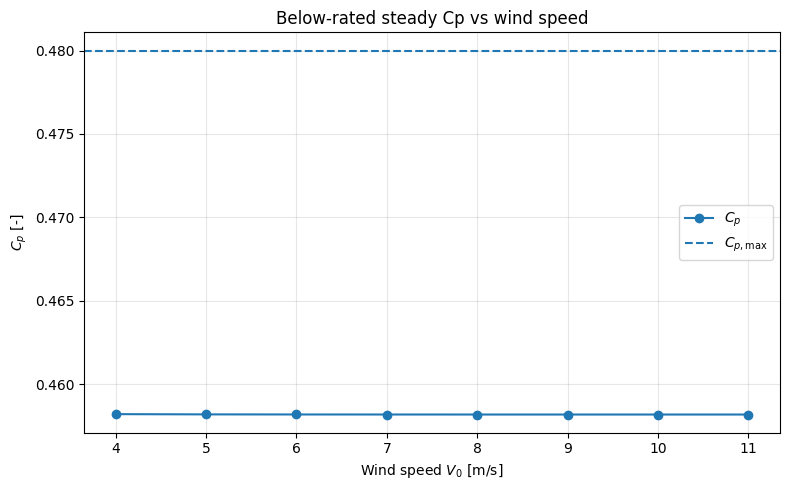

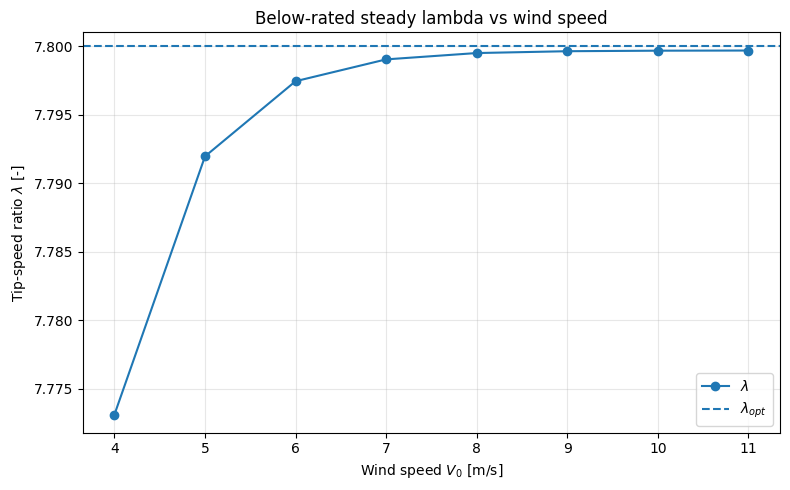

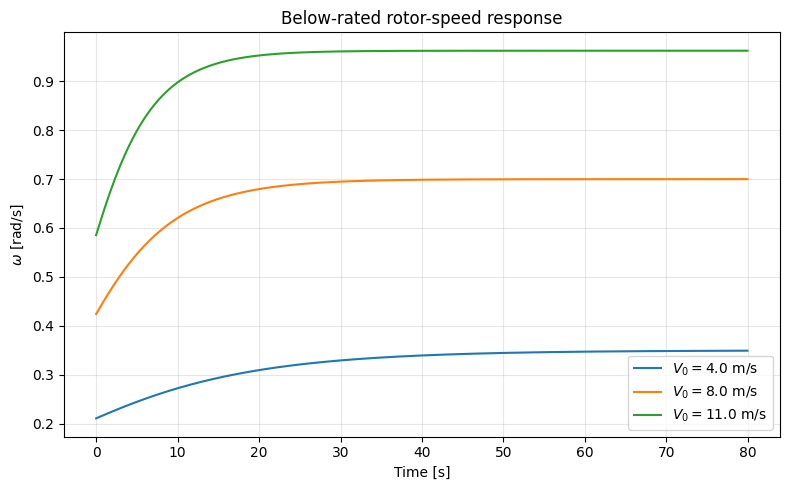

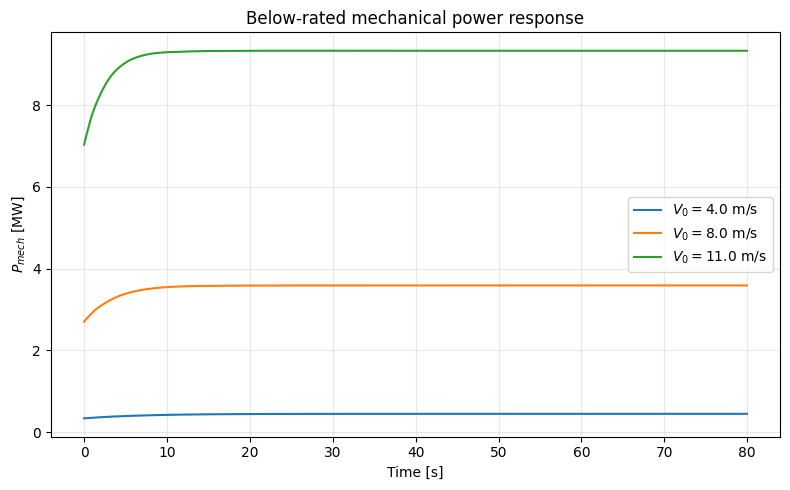

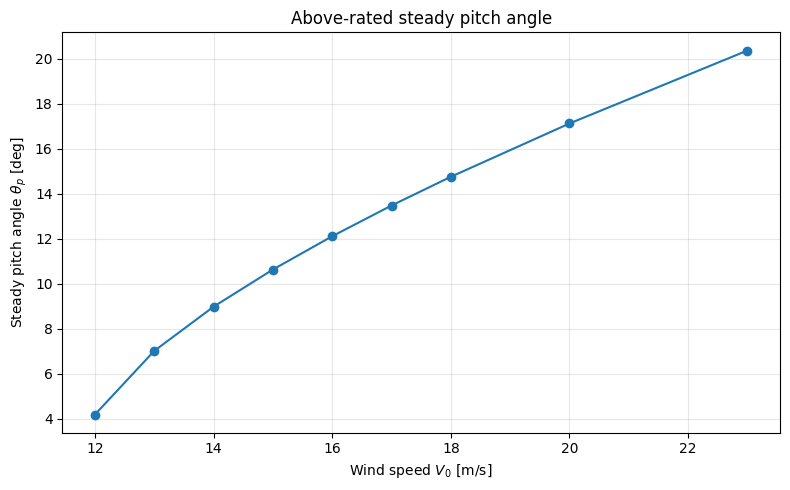

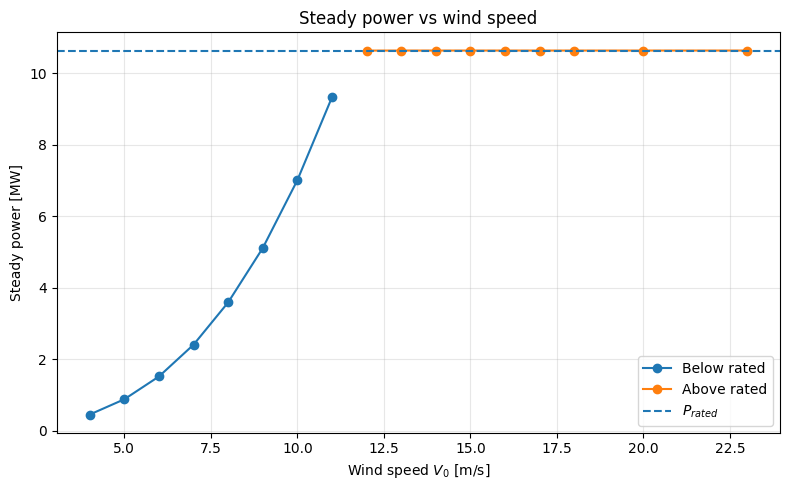

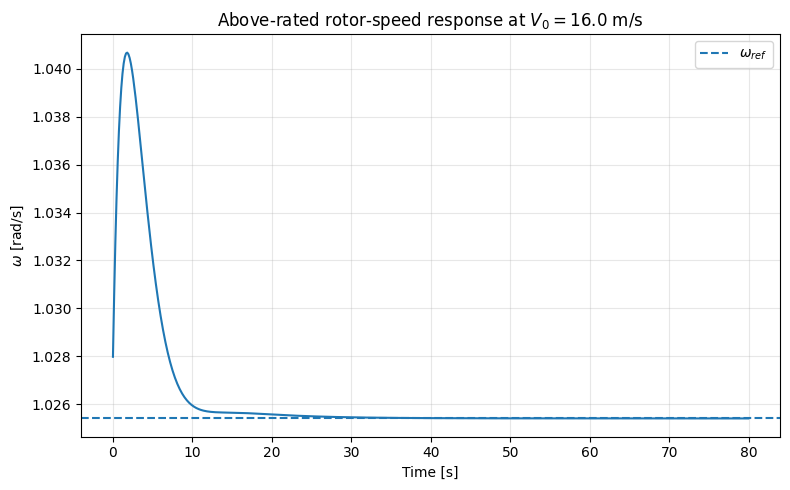

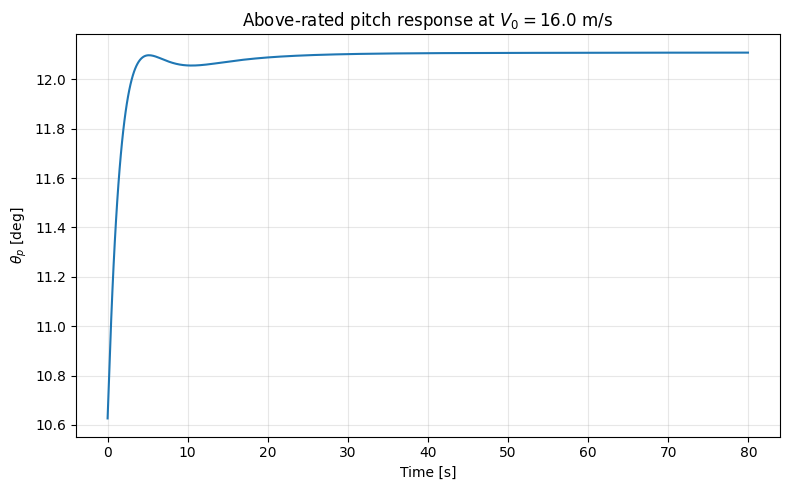

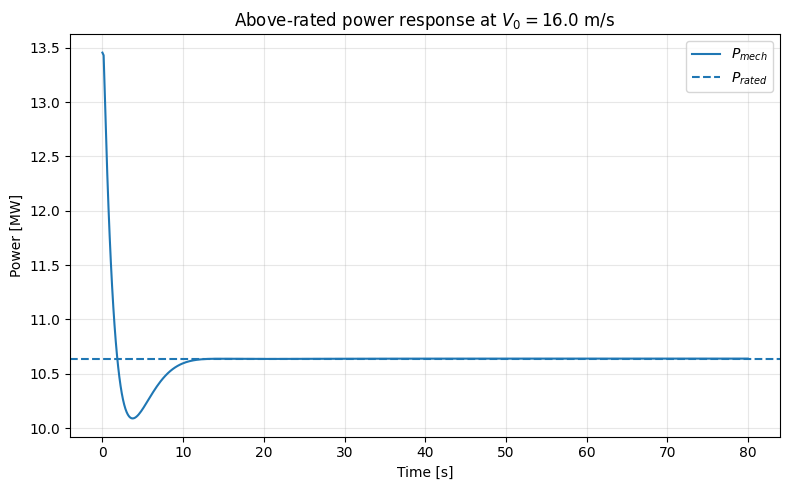

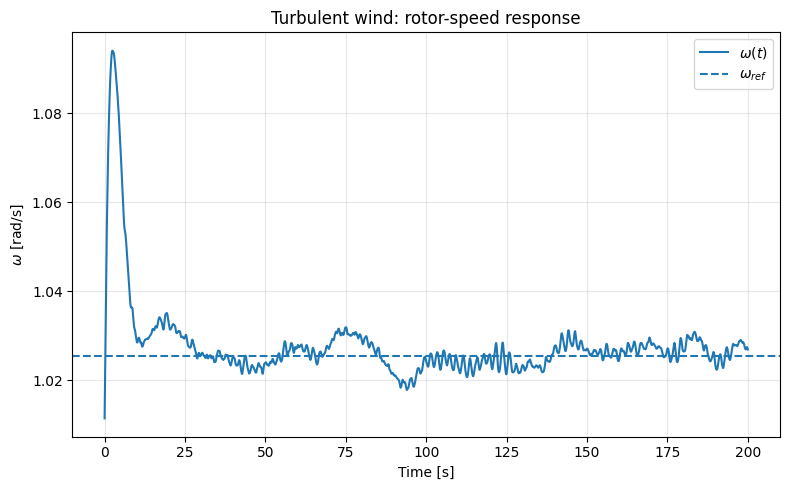

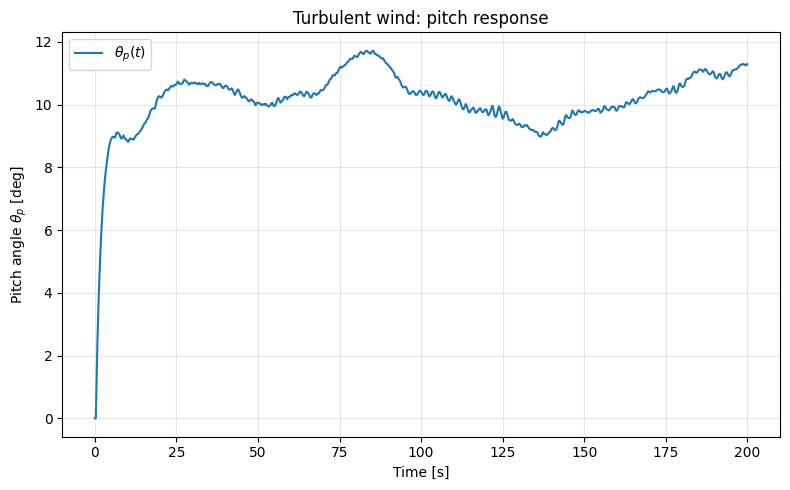

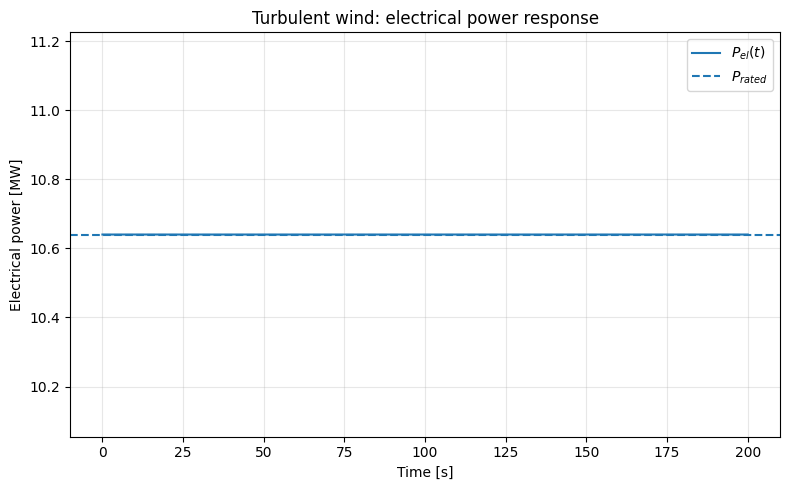

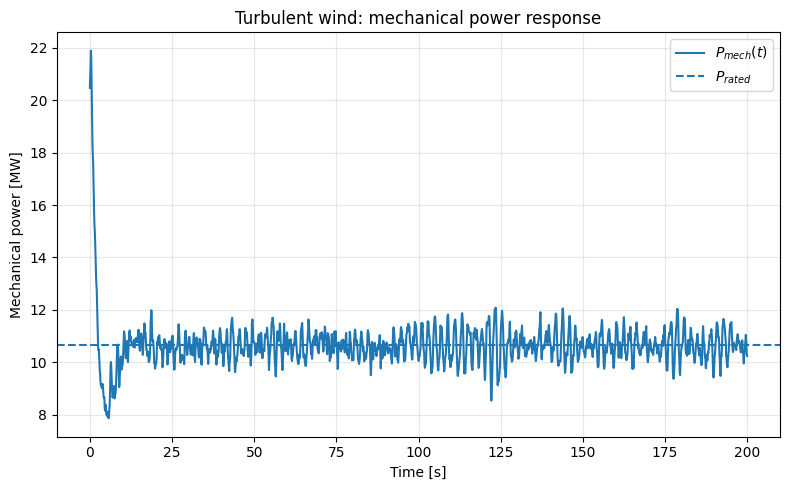

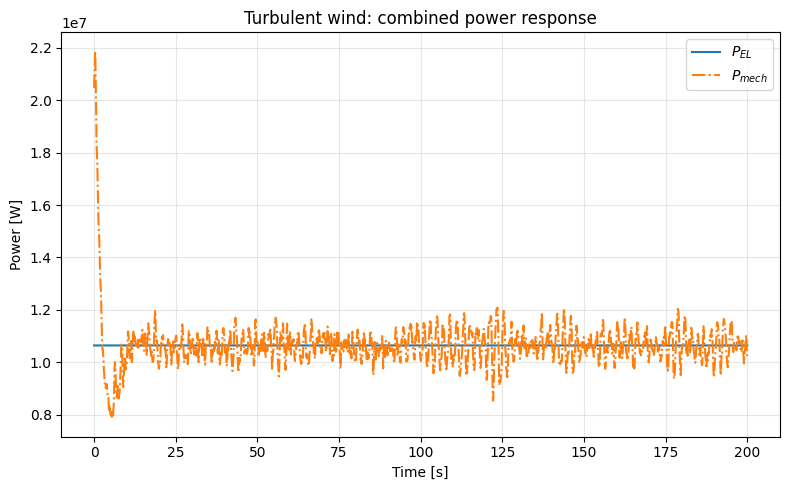

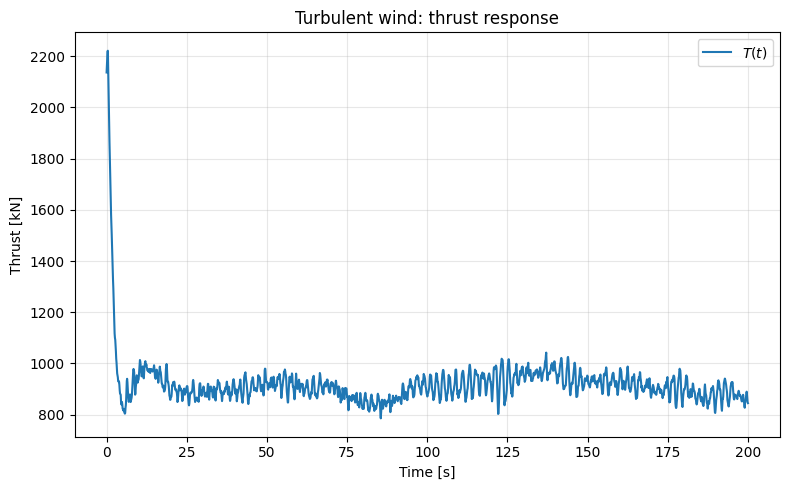

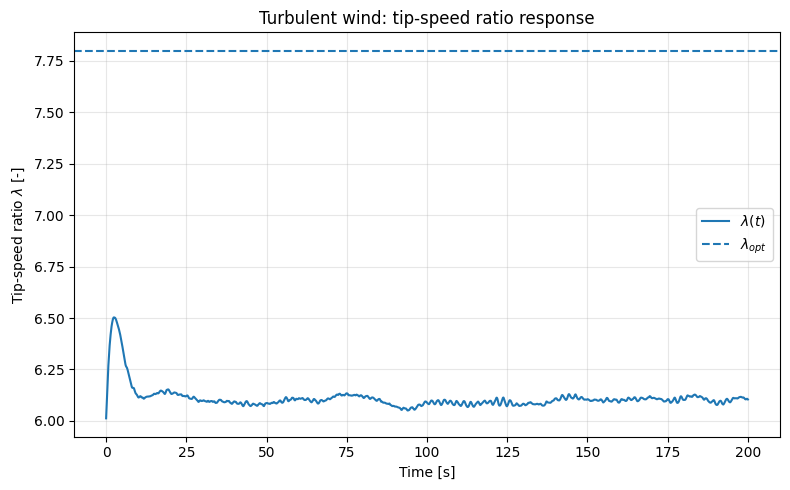

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SIMPLE PLOTS FOR ASSIGNMENT 2
# Assumes these variables already exist:
#   below_results, above_results, turb_case, rated
# ============================================================

# ----------------------------
# Output folder
# ----------------------------
OUT_DIR = "assignment 2"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------
# Sort results
# ----------------------------
below_sorted = sorted(below_results, key=lambda d: d["V0"])
above_sorted = sortedabove_sorted = sorted(above_results, key=lambda d: d["V0"])

# ============================================================
# BELOW-RATED
# ============================================================
V0_below = np.array([case["V0"] for case in below_sorted], dtype=float)
Cp_final_below = np.array([case["Cp_final"] for case in below_sorted], dtype=float)
lambda_final_below = np.array([case["lambda_final"] for case in below_sorted], dtype=float)
P_final_below = np.array([case["P_mech_final"] for case in below_sorted], dtype=float) / 1e6

# 1) Final Cp vs V0
plt.figure(figsize=(8, 5))
plt.plot(V0_below, Cp_final_below, marker="o", label=r"$C_p$")
plt.axhline(CP_MAX, linestyle="--", label=r"$C_{p,\max}$")
plt.xlabel(r"Wind speed $V_0$ [m/s]")
plt.ylabel(r"$C_p$ [-]")
plt.title("Below-rated steady Cp vs wind speed")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "01_below_rated_Cp_vs_V0.pdf"), bbox_inches="tight")

# 2) Final lambda vs V0
plt.figure(figsize=(8, 5))
plt.plot(V0_below, lambda_final_below, marker="o", label=r"$\lambda$")
plt.axhline(LAMBDA_OPT, linestyle="--", label=r"$\lambda_{opt}$")
plt.xlabel(r"Wind speed $V_0$ [m/s]")
plt.ylabel(r"Tip-speed ratio $\lambda$ [-]")
plt.title("Below-rated steady lambda vs wind speed")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02_below_rated_lambda_vs_V0.pdf"), bbox_inches="tight")

# 3) omega(t) representative below-rated cases
plt.figure(figsize=(8, 5))
for case in below_sorted:
    if np.isclose(case["V0"], 4.0) or np.isclose(case["V0"], 8.0) or np.isclose(case["V0"], 11.0):
        plt.plot(case["t"], case["omega"], label=fr"$V_0={case['V0']:.1f}$ m/s")
plt.xlabel("Time [s]")
plt.ylabel(r"$\omega$ [rad/s]")
plt.title("Below-rated rotor-speed response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03_below_rated_omega_response.pdf"), bbox_inches="tight")

# 4) P_mech(t) representative below-rated cases
plt.figure(figsize=(8, 5))
for case in below_sorted:
    if np.isclose(case["V0"], 4.0) or np.isclose(case["V0"], 8.0) or np.isclose(case["V0"], 11.0):
        plt.plot(case["t"], np.array(case["P_mech"]) / 1e6, label=fr"$V_0={case['V0']:.1f}$ m/s")
plt.xlabel("Time [s]")
plt.ylabel(r"$P_{mech}$ [MW]")
plt.title("Below-rated mechanical power response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "04_below_rated_Pmech_response.pdf"), bbox_inches="tight")

# ============================================================
# ABOVE-RATED
# ============================================================
V0_above = np.array([case["V0"] for case in above_sorted], dtype=float)
theta_final_above = np.array([case["pitch_final_deg"] for case in above_sorted], dtype=float)
P_final_above = np.array([case["P_mech_final"] for case in above_sorted], dtype=float) / 1e6

# 5) Final pitch vs V0
plt.figure(figsize=(8, 5))
plt.plot(V0_above, theta_final_above, marker="o")
plt.xlabel(r"Wind speed $V_0$ [m/s]")
plt.ylabel(r"Steady pitch angle $\theta_p$ [deg]")
plt.title("Above-rated steady pitch angle")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "05_above_rated_pitch_vs_V0.pdf"), bbox_inches="tight")

# 6) Steady power vs V0
plt.figure(figsize=(8, 5))
plt.plot(V0_below, P_final_below, marker="o", label="Below rated")
plt.plot(V0_above, P_final_above, marker="o", label="Above rated")
plt.axhline(P_RATED / 1e6, linestyle="--", label=r"$P_{rated}$")
plt.xlabel(r"Wind speed $V_0$ [m/s]")
plt.ylabel("Steady power [MW]")
plt.title("Steady power vs wind speed")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "06_steady_power_vs_V0.pdf"), bbox_inches="tight")

# 7) Representative above-rated case
case_rep = above_sorted[len(above_sorted) // 2]

plt.figure(figsize=(8, 5))
plt.plot(case_rep["t"], case_rep["omega"])
plt.axhline(rated["omega_ref"], linestyle="--", label=r"$\omega_{ref}$")
plt.xlabel("Time [s]")
plt.ylabel(r"$\omega$ [rad/s]")
plt.title(fr"Above-rated rotor-speed response at $V_0={case_rep['V0']:.1f}$ m/s")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "07_above_rated_omega_response.pdf"), bbox_inches="tight")

plt.figure(figsize=(8, 5))
plt.plot(case_rep["t"], case_rep["pitch_deg"])
plt.xlabel("Time [s]")
plt.ylabel(r"$\theta_p$ [deg]")
plt.title(fr"Above-rated pitch response at $V_0={case_rep['V0']:.1f}$ m/s")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_above_rated_pitch_response.pdf"), bbox_inches="tight")

plt.figure(figsize=(8, 5))
plt.plot(case_rep["t"], np.array(case_rep["P_mech"]) / 1e6, label=r"$P_{mech}$")
plt.axhline(P_RATED / 1e6, linestyle="--", label=r"$P_{rated}$")
plt.xlabel("Time [s]")
plt.ylabel("Power [MW]")
plt.title(fr"Above-rated power response at $V_0={case_rep['V0']:.1f}$ m/s")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_above_rated_power_response.pdf"), bbox_inches="tight")

# ============================================================
# TURBULENT-WIND
# ============================================================
# 10) omega(t)
plt.figure(figsize=(8, 5))
plt.plot(turb_case["t"], turb_case["omega"], label=r"$\omega(t)$")
plt.axhline(rated["omega_ref"], linestyle="--", label=r"$\omega_{ref}$")
plt.xlabel("Time [s]")
plt.ylabel(r"$\omega$ [rad/s]")
plt.title("Turbulent wind: rotor-speed response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "10_turbulent_omega_response.pdf"), bbox_inches="tight")

# 11) pitch(t)
plt.figure(figsize=(8, 5))
plt.plot(turb_case["t"], turb_case["pitch_deg"], label=r"$\theta_p(t)$")
plt.xlabel("Time [s]")
plt.ylabel(r"Pitch angle $\theta_p$ [deg]")
plt.title("Turbulent wind: pitch response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "11_turbulent_pitch_response.pdf"), bbox_inches="tight")

# 12) electrical power
plt.figure(figsize=(8, 5))
plt.plot(turb_case["t"], np.array(turb_case["P_el"]) / 1e6, label=r"$P_{el}(t)$")
plt.axhline(P_RATED / 1e6, linestyle="--", label=r"$P_{rated}$")
plt.xlabel("Time [s]")
plt.ylabel("Electrical power [MW]")
plt.title("Turbulent wind: electrical power response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "12_turbulent_Pel_response.pdf"), bbox_inches="tight")

# 13) mechanical power
plt.figure(figsize=(8, 5))
plt.plot(turb_case["t"], np.array(turb_case["P_mech"]) / 1e6, label=r"$P_{mech}(t)$")
plt.axhline(P_RATED / 1e6, linestyle="--", label=r"$P_{rated}$")
plt.xlabel("Time [s]")
plt.ylabel("Mechanical power [MW]")
plt.title("Turbulent wind: mechanical power response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "13_turbulent_Pmech_response.pdf"), bbox_inches="tight")

# 14) combined electrical + mechanical power
plt.figure(figsize=(8, 5))
plt.plot(turb_case["t"], np.array(turb_case["P_el"]), label=r"$P_{EL}$")
plt.plot(turb_case["t"], np.array(turb_case["P_mech"]), "-.", label=r"$P_{mech}$")
plt.xlabel("Time [s]")
plt.ylabel("Power [W]")
plt.title("Turbulent wind: combined power response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "14_turbulent_combined_power_response.pdf"), bbox_inches="tight")

# 15) thrust
plt.figure(figsize=(8, 5))
plt.plot(turb_case["t"], np.array(turb_case["T_total"]) / 1e3, label=r"$T(t)$")
plt.xlabel("Time [s]")
plt.ylabel("Thrust [kN]")
plt.title("Turbulent wind: thrust response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "15_turbulent_thrust_response.pdf"), bbox_inches="tight")

# 16) tip-speed ratio
plt.figure(figsize=(8, 5))
plt.plot(turb_case["t"], turb_case["lambda"], label=r"$\lambda(t)$")
plt.axhline(LAMBDA_OPT, linestyle="--", label=r"$\lambda_{opt}$")
plt.xlabel("Time [s]")
plt.ylabel(r"Tip-speed ratio $\lambda$ [-]")
plt.title("Turbulent wind: tip-speed ratio response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "16_turbulent_lambda_response.pdf"), bbox_inches="tight")

plt.show()
plt.close("all")